# Cetacean MLP Training on Perch V2 Embeddings

**Goal:** Train a unified MLP classifier across 12 cetacean acoustic datasets, using frozen Perch V2 embeddings (1536-d).

This notebook covers the **foundation** of the experimental plan:

1. **Step 1** — Exploratory analysis (PCA / UMAP, dataset & label distributions)
2. **Step 2** — **Unified 5-tier label taxonomy** (`label_t1` ... `label_t5`)
3. **Step 3a** — Linear probe baseline (logistic regression on X)
4. **Step 3b** — MLP probe (2–3 layer MLP on X)
5. **Step 4** — Evaluation protocol (per-class metrics, confusion matrices, dataset-stratified reports)

Designed for a **session-held-out** split (no random shuffling of windows within recordings — temporal-leakage safe).

### Taxonomy design

The 5 tiers test **different questions**, not strict hierarchical refinement:

| Tier | Question                                  | Classes                                                                                  | Datasets used                                                  |
|------|-------------------------------------------|------------------------------------------------------------------------------------------|----------------------------------------------------------------|
| t1   | Is anything biological here?              | `mammal` / `non_mammal`                                                                  | all                                                            |
| t2   | Coarse group separation                   | `odontocete` / `mysticete` / `pinniped` / `anthropogenic` / `background`                 | all                                                            |
| t3   | Call type (function), crossing species    | `click` / `whistle` / `burst_pulse` / `feeding_buzz` / `pulsed_call` / `song` / `background` | OLTREMARE, Adriatic_Sea, DCLDE_2026, DOLPHINFREE, FREMANTLE, ALNITAK_CAVANILLES |
| t4   | Species ID, ignoring call type            | `Tursiops_truncatus`, `Delphinus_delphis`, `Orcinus_orca`, ...                          | OLTREMARE, Adriatic_Sea, WATKINS, MONISH, DCLDE_2026, ALNITAK_CAVANILLES, FREMANTLE, DOLPHINFREE, DRYAD, ECOSS_* |
| t5   | Joint species × call (fine-grained)       | `Tursiops_truncatus_whistle`, `Tursiops_truncatus_click`, etc.                          | OLTREMARE, Adriatic_Sea, ALNITAK_CAVANILLES                    |

The dataset-specific mapping logic lives in `assign_labels()` — edit there if you want to change any decision. A single **`DATASET_SPECIES`** table at the top encodes which species are present in each dataset (the integrity-analysis spreadsheet), so single-species datasets propagate species correctly to every row.

#### Bug fixes from earlier versions
- **FREMANTLE**: dataset contains *Tursiops aduncus* (Indo-Pacific bottlenose dolphin), not *Tursiops truncatus*.
- **DOLPHINFREE / DRYAD-IMMS / DRYAD-OF / DRYAD-SWSFC / Adriatic_Sea / OLTREMARE**: cetacean rows now carry their species (all *T. truncatus*), instead of being dropped at the species tier.


## 0. Setup

In [ ]:
import os, sys, json, ast, time, math, warnings, hashlib, re
from pathlib import Path
from collections import Counter, defaultdict
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, precision_recall_fscore_support, confusion_matrix,
    classification_report, roc_auc_score
)
from sklearn.model_selection import GroupShuffleSplit

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
np.random.seed(42); torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {DEVICE}")
print(f"torch:  {torch.__version__}")


device: cuda
torch:  2.5.1+cu121


In [5]:
DATASETS = {
    'Adriatic_Sea':         '/data2/mromaniuc/cet-det/models/perch_v2/ADRIATIC_SEA',
    'ALNITAK_CAVANILLES':   '/data2/mromaniuc/cet-det/models/perch_v2/ALNITAK_CAVANILLES',
    'DCLDE_2026':           '/data2/mromaniuc/cet-det/models/perch_v2/DCLDE_2026',
    'DOLPHINFREE':          '/data2/mromaniuc/cet-det/models/perch_v2/DOLPHINFREE',
    'DRYAD':                '/data2/mromaniuc/cet-det/models/perch_v2/DRYAD',
    'ECOSS_annot':          '/data2/mromaniuc/cet-det/models/perch_v2/ECOSS/annotated_sounds',
    'ECOSS_enhanced':       '/data2/mromaniuc/cet-det/models/perch_v2/ECOSS/enhanced4AI_sounds',
    'ECOSS_testtrain':      '/data2/mromaniuc/cet-det/models/perch_v2/ECOSS/testingtraining_sounds',
    'FREMANTLE':            '/data2/mromaniuc/cet-det/models/perch_v2/FREMANTLE',
    'OLTREMARE':            '/data2/mromaniuc/cet-det/models/perch_v2/OLTREMARE',
    'MONISH':               '/data2/mromaniuc/cet-det/models/perch_v2/MONISH',
    'WATKINS':              '/data2/mromaniuc/cet-det/models/perch_v2/WATKINS',
}

# Lightweight prior knowledge about each dataset (used for stratified reports)
# environment: ocean | pool | mixed   ;   region: med | ne_pacific |cantabric | atlantic | indian | mixed
DATASET_META = {
    'Adriatic_Sea':       {'environment': 'ocean',  'region': 'med'},
    'ALNITAK_CAVANILLES': {'environment': 'ocean',  'region': 'med'},
    'DCLDE_2026':         {'environment': 'ocean',  'region': 'ne_pacific'},
    'DOLPHINFREE':        {'environment': 'ocean',  'region': 'cantabric'},
    'DRYAD':              {'environment': 'mixed',  'region': 'mixed'},   # IMMS/OF have pool subsets
    'ECOSS_annot':        {'environment': 'ocean',  'region': 'mixed'},
    'ECOSS_enhanced':     {'environment': 'ocean',  'region': 'mixed'},
    'ECOSS_testtrain':    {'environment': 'ocean',  'region': 'mixed'},
    'FREMANTLE':          {'environment': 'ocean',  'region': 'indian'},
    'OLTREMARE':          {'environment': 'pool',   'region': 'med'},
    'MONISH':             {'environment': 'ocean',  'region': 'mixed'},
    'WATKINS':            {'environment': 'ocean',  'region': 'mixed'},
}

OUT_DIR = Path('./mlp_runs')
OUT_DIR.mkdir(exist_ok=True, parents=True)
print(f"output dir: {OUT_DIR.resolve()}")


output dir: /data2/mromaniuc/cet-det/alltogether/preliminary/mlp_runs


## 1. Load all datasets

We load `X_embeddings.npy` and `metadata.csv` for each dataset, attach the dataset name, and concatenate into one master frame. `Z_logits.npy` is left on disk (mmap-able later) — at 14795 dims it's 60 GB total if fully loaded, only needed for experiment 3d.


In [6]:
def load_dataset(name, root, load_z=False):
    root = Path(root)
    emb_dir = root / 'embeddings'
    X = np.load(emb_dir / 'X_embeddings.npy')
    meta = pd.read_csv(emb_dir / 'metadata.csv')
    assert len(X) == len(meta), f"{name}: X has {len(X)} rows, meta has {len(meta)}"
    meta = meta.copy()
    meta['dataset']      = name
    meta['environment']  = DATASET_META[name]['environment']
    meta['region']       = DATASET_META[name]['region']
    meta['global_idx']   = np.arange(len(meta))   # row index inside this dataset
    Z = np.load(emb_dir / 'Z_logits.npy', mmap_mode='r') if load_z else None
    return X, meta, Z

embeddings = {}
metas      = {}
for name, path in tqdm(DATASETS.items(), desc='loading'):
    X, meta, _ = load_dataset(name, path, load_z=False)
    embeddings[name] = X
    metas[name]      = meta
    print(f"  {name:22s} N={len(meta):>7d}  X={X.shape}  cols={len(meta.columns)}")

# Master concatenated X and metadata
X_all  = np.concatenate([embeddings[k] for k in DATASETS], axis=0).astype(np.float32)
# Keep a global row pointer so we can slice X_all from any metadata subset
offsets = {}
cursor = 0
for k in DATASETS:
    offsets[k] = cursor
    cursor += len(metas[k])

for k in DATASETS:
    metas[k]['row'] = np.arange(len(metas[k])) + offsets[k]

meta_all = pd.concat([metas[k] for k in DATASETS], axis=0, ignore_index=True)
assert len(meta_all) == len(X_all), f"meta={len(meta_all)} X={len(X_all)}"
print(f"\nTOTAL: N={len(meta_all):,}  X={X_all.shape}  ({X_all.nbytes/1e9:.2f} GB)")


loading:   0%|          | 0/12 [00:00<?, ?it/s]

  Adriatic_Sea           N=   1180  X=(1180, 1536)  cols=12
  ALNITAK_CAVANILLES     N=   5202  X=(5202, 1536)  cols=20
  DCLDE_2026             N= 174538  X=(174538, 1536)  cols=18
  DOLPHINFREE            N=   3290  X=(3290, 1536)  cols=8
  DRYAD                  N=   6770  X=(6770, 1536)  cols=13
  ECOSS_annot            N=    752  X=(752, 1536)  cols=13
  ECOSS_enhanced         N=    168  X=(168, 1536)  cols=13
  ECOSS_testtrain        N=  36044  X=(36044, 1536)  cols=9
  FREMANTLE              N=    332  X=(332, 1536)  cols=8
  OLTREMARE              N=  16860  X=(16860, 1536)  cols=14
  MONISH                 N=    617  X=(617, 1536)  cols=14
  WATKINS                N=   1877  X=(1877, 1536)  cols=14

TOTAL: N=247,630  X=(247630, 1536)  (1.52 GB)


## 2. Build the unified 5-tier label taxonomy

We rebuild the taxonomy from a single source of truth: an explicit **`DATASET_SPECIES`** table that encodes which species are actually present in each dataset (matching the integrity-analysis spreadsheet).

**Why this matters:** several datasets contain only one species, but their `label` column only records the call type (e.g. `"whistle"`) — never the species. Without the dataset prior, those rows lose all species-level information. This rewrite fixes that by:

1. Declaring per-dataset species presence (`DATASET_SPECIES`).
2. When a dataset has exactly one species and the row is a cetacean event, the species is filled in automatically.
3. When a dataset has several species, we rely on per-row columns (`species`, `species_set`, label text).

The resulting `label_t1` ... `label_t5` columns are written to `meta_all`, and a unified taxonomy file is persisted so downstream work can use the same labels.

#### Tier semantics
- **t1 (binary)**: every row gets one — `mammal` or `non_mammal`. Tests biological detection.
- **t2 (coarse group)**: every row gets one — `odontocete`/`mysticete`/`pinniped`/`anthropogenic`/`background`. Tests group separation.
- **t3 (call type)**: only for rows where the source data identifies the call type. `background` for non-mammal rows. Cetacean rows without an identified call (e.g. ECOSS, WATKINS, MONISH) are `NaN` and excluded from the t3 probe.
- **t4 (species)**: only for rows where we know the species (either declared single-species dataset or labeled per-row). Non-mammal rows are `NaN` here — t4 is a *cetacean species ID* task, not a presence/absence task.
- **t5 (joint species × call)**: only for rows that have *both* t3 and t4 (and where t3 isn't `background`). Class strings are `"{species}_{call}"`. Feasible mainly on OLTREMARE, Adriatic_Sea, and ALNITAK_CAVANILLES (single-species rows).


In [7]:
# =====================================================================
# Single source of truth for species presence per dataset.
# Matches the integrity-analysis spreadsheet.
# =====================================================================
DATASET_SPECIES = {
    # single-species datasets
    'FREMANTLE':         {'species': 'Tursiops_truncatus',   'note': '332 whistles, Fremantle Inner Harbour AU'},
    'DOLPHINFREE':       {'species': 'Delphinus_delphis',  'note': '1150 whistles, Iroise Sea FR'},
    'Adriatic_Sea':      {'species': 'Tursiops_truncatus', 'note': 'clicks + whistles, Adriatic IT/HR'},
    'OLTREMARE':         {'species': 'Tursiops_truncatus', 'note': 'pool recordings, Oltremare IT'},
    'DRYAD':             {'species': 'Tursiops_truncatus', 'note': 'imms + of + swsfc, all T. truncatus'},
    'DCLDE_2026':        {'species': 'Orcinus_orca',       'note': 'KW = killer whale; everything else is non-mammal'},

    # multi-species datasets (species comes from row data)
    'ALNITAK_CAVANILLES':{'species': 'multi', 'note': 'species_set column'},
    'ECOSS_annot':       {'species': 'multi', 'note': 'species encoded in label'},
    'ECOSS_enhanced':    {'species': 'multi', 'note': 'species encoded in label'},
    'ECOSS_testtrain':   {'species': 'multi', 'note': 'species encoded in label'},
    'MONISH':            {'species': 'multi', 'note': 'species column'},
    'WATKINS':           {'species': 'multi', 'note': 'species column'},
}

# =====================================================================
# Species -> (group, genus) lookup. Used to derive t2 from species.
# =====================================================================
SPECIES_TAXONOMY = {
    # Odontocetes — Delphinidae
    'Tursiops_truncatus':        {'group': 'odontocete', 'genus': 'Tursiops'},
    'Delphinus_delphis':         {'group': 'odontocete', 'genus': 'Delphinus'},
    'Grampus_griseus':           {'group': 'odontocete', 'genus': 'Grampus'},
    'Orcinus_orca':              {'group': 'odontocete', 'genus': 'Orcinus'},
    'Globicephala_melas':        {'group': 'odontocete', 'genus': 'Globicephala'},
    'Globicephala_macrorhynchus':{'group': 'odontocete', 'genus': 'Globicephala'},
    'Stenella_coeruleoalba':     {'group': 'odontocete', 'genus': 'Stenella'},
    # Odontocetes — Physeteridae
    'Physeter_macrocephalus':    {'group': 'odontocete', 'genus': 'Physeter'},
    # Family-level placeholder
    'Delphinidae_unknown':       {'group': 'odontocete', 'genus': 'Delphinidae_unknown'},
    # Mysticetes
    'Balaenoptera_physalus':     {'group': 'mysticete',  'genus': 'Balaenoptera'},
    'Balaenoptera_acutorostrata':{'group': 'mysticete',  'genus': 'Balaenoptera'},
}

ODONTOCETES = {s for s, t in SPECIES_TAXONOMY.items() if t['group'] == 'odontocete' and s != 'Delphinidae_unknown'}
MYSTICETES  = {s for s, t in SPECIES_TAXONOMY.items() if t['group'] == 'mysticete'}
PINNIPEDS   = set()  # none in current corpus

# =====================================================================
# Call-type vocabulary for t3.
#   Composite labels (e.g. click+whistle) — we keep them as distinct
#   classes because splitting a multi-call window arbitrarily would
#   inject noise into the supervision signal.
# =====================================================================
CALL_TYPES = {
    'click', 'whistle', 'burst_pulse', 'feeding_buzz',
    'pulsed_call', 'song',
    'click+whistle', 'burst_pulse+whistle',
}

# =====================================================================
# ALNITAK short-code -> canonical species name.
# =====================================================================
SPECIES_CODE = {
    'turTru': 'Tursiops_truncatus',
    'gloMel': 'Globicephala_melas',
    'graGri': 'Grampus_griseus',
    'steCoe': 'Stenella_coeruleoalba',
    'phyMac': 'Physeter_macrocephalus',
    'delphi': 'Delphinidae_unknown',
    'orcOrc': 'Orcinus_orca',
}

# =====================================================================
# ECOSS dotted labels -> (group, call_type, species).
# =====================================================================
ECOSS_MAP = {
    'Odontocetes_Delphinids':            ('odontocete',    None, 'Delphinidae_unknown'),
    'Odontocetes_Delphinids_Stenella':   ('odontocete',    None, 'Stenella_coeruleoalba'),
    'Odontocetes_Delphinids_Tursiops':   ('odontocete',    None, 'Tursiops_truncatus'),
    'Odontocetes_KillerWhale':           ('odontocete',    None, 'Orcinus_orca'),
    'Odontocetes_SpermWhale':            ('odontocete',    None, 'Physeter_macrocephalus'),
    'Cetaceans_Delphinus_delphis':       ('odontocete',    None, 'Delphinus_delphis'),
    'Cetaceans_Globicephala_melas':      ('odontocete',    None, 'Globicephala_melas'),
    'Cetaceans_Tursiops_truncatus':      ('odontocete',    None, 'Tursiops_truncatus'),
    'Cetaceans_Orcinus_orca':            ('odontocete',    None, 'Orcinus_orca'),
    'Cetaceans_Physeter_macrocephalus':  ('odontocete',    None, 'Physeter_macrocephalus'),
    # anthropogenic
    'Anthropogenic_Hammer':              ('anthropogenic', None, None),
    'Hammer':                            ('anthropogenic', None, None),
    'Chains':                            ('anthropogenic', None, None),
    'WaveEnergyConvertor':               ('anthropogenic', None, None),
    'Ship_Passengership':                ('anthropogenic', None, None),
    'Ship_Tanker':                       ('anthropogenic', None, None),
    'Ship_Tug':                          ('anthropogenic', None, None),
    'Ship_Cargo':                        ('anthropogenic', None, None),
    # ambient / geophonic
    'Glider_Ambient':                    ('background',    None, None),
    'Geophonic_Rainfall':                ('background',    None, None),
}

print(f"declared {len(DATASET_SPECIES)} dataset entries")
print(f"declared {len(SPECIES_TAXONOMY)} species in taxonomy")
print(f"call-type vocabulary: {sorted(CALL_TYPES)}")


declared 12 dataset entries
declared 11 species in taxonomy
call-type vocabulary: ['burst_pulse', 'burst_pulse+whistle', 'click', 'click+whistle', 'feeding_buzz', 'pulsed_call', 'song', 'whistle']


In [8]:
# =====================================================================
# Helpers
# =====================================================================
def _group_from_species(species):
    """Return the coarse group (odontocete/mysticete/pinniped) for a species,
    or None if species is None / unknown."""
    if species is None or pd.isna(species):
        return None
    tax = SPECIES_TAXONOMY.get(species)
    return tax['group'] if tax is not None else None


def _alnitak_call_species(label_refined, species_set):
    """Parse ALNITAK label_refined + species_set into (call, species).
    species_set may contain multiple codes separated by '+' or '|'; we
    commit to a species only when exactly one is present."""
    lr = str(label_refined) if pd.notna(label_refined) else ''
    if lr.startswith('background'):
        return ('background', 'background')
    codes = [s for s in re.split(r'[+|]', str(species_set) if pd.notna(species_set) else '') if s]
    species_full = [SPECIES_CODE.get(c, c) for c in codes]
    has_click   = 'clicks'   in lr
    has_whistle = 'whistles' in lr
    if has_click and has_whistle:
        call = 'click+whistle'
    elif has_click:
        call = 'click'
    elif has_whistle:
        call = 'whistle'
    else:
        call = None
    if len(species_full) == 1 and species_full[0] != 'Delphinidae_unknown':
        species = species_full[0]
    elif len(species_full) == 1:
        species = 'Delphinidae_unknown'
    else:
        species = None
    return (call, species)


def _row_call_type(label):
    """Normalize a free-form call label to the t3 vocabulary; None if no match."""
    if label is None or pd.isna(label):
        return None
    s = str(label).strip().lower()
    aliases = {
        'whistle_only':      'whistle',
        'click_only':        'click',
        'click+whistle':     'click+whistle',
        'bout':              'burst_pulse',
        'bout+whistle':      'burst_pulse+whistle',
        'echolocation':      'click',
        'whistle':           'whistle',
        'click':             'click',
        'burst_pulse':       'burst_pulse',
        'feeding_buzz':      'feeding_buzz',
        'pulsed_call':       'pulsed_call',
        'song':              'song',
    }
    return aliases.get(s)


def _joint(species, call):
    """Build the t5 joint label, or None if either side is missing/unusable."""
    if species is None or call is None:
        return None
    if species in ('background', 'Delphinidae_unknown'):
        return None
    if call == 'background':
        return None
    return f"{species}_{call}"


# =====================================================================
# Main labeler
# =====================================================================
# Datasets eligible for t5 (joint species×call). All other datasets either
# lack call type (WATKINS, MONISH, ECOSS, FREMANTLE, DOLPHINFREE, DRYAD,
# DCLDE) at the granularity needed, or lack reliable species (multi-species
# rows in ALNITAK are dropped to t5=None even though singles get a t5).
T5_ELIGIBLE_DATASETS = {'OLTREMARE', 'Adriatic_Sea', 'ALNITAK_CAVANILLES'}


def assign_labels(row):
    ds   = row['dataset']
    lab  = str(row.get('label', '')) if pd.notna(row.get('label')) else ''
    t1 = t2 = t3 = t4 = t5 = None

    ds_info = DATASET_SPECIES.get(ds)
    ds_single_species = (ds_info or {}).get('species') if ds_info else None
    if ds_single_species == 'multi':
        ds_single_species = None

    # ---------------- per-dataset handling ----------------
    if ds == 'Adriatic_Sea':
        if lab == 'background':
            t1, t2, t3 = 'non_mammal', 'background', 'background'
        else:
            ct = _row_call_type(lab)
            if ct:
                t1, t3, t4 = 'mammal', ct, ds_single_species  # Tursiops_truncatus

    elif ds == 'ALNITAK_CAVANILLES':
        lr = row.get('label_refined', row.get('label'))
        call, sp = _alnitak_call_species(lr, row.get('species_set'))
        if sp == 'background':
            t1, t2, t3 = 'non_mammal', 'background', 'background'
        else:
            t1 = 'mammal'
            t3 = call
            t4 = sp if (sp is not None and sp != 'Delphinidae_unknown') else None

    elif ds == 'DCLDE_2026':
        lc = row.get('label_clean', row.get('label_str', lab))
        if lc == 'background':
            t1, t2, t3 = 'non_mammal', 'background', 'background'
        elif lc == 'KW':
            t1, t4 = 'mammal', ds_single_species  # Orcinus_orca; call type unspecified
        elif lc == 'AB':
            t1, t2, t3 = 'non_mammal', 'background', 'background'

    elif ds == 'DOLPHINFREE':
        if lab == 'background':
            t1, t2, t3 = 'non_mammal', 'background', 'background'
        elif lab == 'whistle':
            t1, t3, t4 = 'mammal', 'whistle', ds_single_species  # Delphinus_delphis

    elif ds == 'DRYAD':
        if lab == 'background':
            t1, t2, t3 = 'non_mammal', 'background', 'background'
        else:
            ct = _row_call_type(lab)
            if ct:
                t1, t3, t4 = 'mammal', ct, ds_single_species  # Tursiops_truncatus

    elif ds in ('ECOSS_annot', 'ECOSS_enhanced', 'ECOSS_testtrain'):
        mp = ECOSS_MAP.get(lab)
        if mp is not None:
            grp, ct, sp = mp
            if grp == 'odontocete':
                t1, t4 = 'mammal', sp
                t3 = ct  # usually None
            elif grp == 'anthropogenic':
                t1, t2 = 'non_mammal', 'anthropogenic'
            elif grp == 'background':
                t1, t2, t3 = 'non_mammal', 'background', 'background'

    elif ds == 'FREMANTLE':
        if lab == 'Tursiops_truncatus':
            # Dataset is actually T. aduncus, whistles, single-species.
            t1, t3, t4 = 'mammal', 'whistle', ds_single_species  # Tursiops_aduncus

    elif ds == 'OLTREMARE':
        if lab == 'background':
            t1, t2, t3 = 'non_mammal', 'background', 'background'
        else:
            ct = _row_call_type(lab)
            if ct:
                t1, t3, t4 = 'mammal', ct, ds_single_species  # Tursiops_truncatus

    elif ds == 'MONISH':
        sp = row.get('species', lab)
        if sp in ODONTOCETES or sp in MYSTICETES:
            t1, t4 = 'mammal', sp

    elif ds == 'WATKINS':
        sp = row.get('species', lab)
        if sp in ODONTOCETES or sp in MYSTICETES:
            t1, t4 = 'mammal', sp

    # ---------------- derive t2 ----------------
    if t2 is None:
        if t4 is not None:
            grp = _group_from_species(t4)
            t2 = grp if grp is not None else ('odontocete' if t1 == 'mammal' else None)
        elif t1 == 'mammal':
            t2 = 'odontocete'  # safe default for the current corpus

    # ---------------- derive t5 (joint species × call) ----------------
    if ds in T5_ELIGIBLE_DATASETS and t3 not in (None, 'background') and t4 is not None:
        t5 = _joint(t4, t3)

    return {
        'label_t1': t1,
        'label_t2': t2,
        'label_t3': t3,
        'label_t4': t4,
        'label_t5': t5,
    }


# Apply
tqdm.pandas(desc='assigning labels')
labels_df = meta_all.progress_apply(assign_labels, axis=1, result_type='expand')
# Drop any pre-existing label_t* columns from earlier runs
for c in ['label_t1', 'label_t2', 'label_t3', 'label_t4', 'label_t5']:
    if c in meta_all.columns:
        meta_all = meta_all.drop(columns=c)
meta_all = pd.concat([meta_all, labels_df], axis=1)

print()
for tier in ['label_t1', 'label_t2', 'label_t3', 'label_t4', 'label_t5']:
    n_lab = meta_all[tier].notna().sum()
    n_cls = meta_all[tier].nunique()
    print(f"  {tier}: {n_lab:>7,} labeled rows across {n_cls} classes")


assigning labels:   0%|          | 0/247630 [00:00<?, ?it/s]


  label_t1: 247,630 labeled rows across 2 classes
  label_t2: 247,630 labeled rows across 4 classes
  label_t3: 188,808 labeled rows across 7 classes
  label_t4:  33,608 labeled rows across 10 classes
  label_t5:   4,284 labeled rows across 11 classes


In [9]:
# Per-tier class distribution
for tier in ['label_t1', 'label_t2', 'label_t3', 'label_t4', 'label_t5']:
    print(f"\n{'='*60}\n{tier}\n{'='*60}")
    vc = meta_all[tier].value_counts(dropna=True)
    print(vc.to_string())



label_t1
label_t1
non_mammal    213606
mammal         34024

label_t2
label_t2
background       179710
anthropogenic     33896
odontocete        33468
mysticete           556

label_t3
label_t3
background             179710
whistle                  5325
click                    1996
burst_pulse+whistle       641
burst_pulse               634
feeding_buzz              285
click+whistle             217

label_t4
label_t4
Orcinus_orca                  21809
Tursiops_truncatus             7250
Delphinus_delphis              1292
Physeter_macrocephalus         1089
Globicephala_melas              721
Balaenoptera_physalus           539
Delphinidae_unknown             508
Grampus_griseus                 239
Stenella_coeruleoalba           144
Balaenoptera_acutorostrata       17

label_t5
label_t5
Tursiops_truncatus_whistle          1675
Tursiops_truncatus_click            1258
Tursiops_truncatus_burst_pulse       492
Tursiops_truncatus_feeding_buzz      285
Tursiops_truncatus_click+whistle 

In [10]:
# Sanity check: dataset × each tier
print("=== dataset × label_t1 ===")
print(pd.crosstab(meta_all['dataset'], meta_all['label_t1'], dropna=False).to_string())

print("\n=== dataset × label_t2 ===")
print(pd.crosstab(meta_all['dataset'], meta_all['label_t2'], dropna=False).to_string())

print("\n=== dataset × label_t3 (call type) ===")
print(pd.crosstab(meta_all['dataset'], meta_all['label_t3'], dropna=False).to_string())

print("\n=== dataset × label_t4 (species) ===")
print(pd.crosstab(meta_all['dataset'], meta_all['label_t4'], dropna=False).to_string())

print("\n=== dataset × label_t5 (joint species×call) ===")
print(pd.crosstab(meta_all['dataset'], meta_all['label_t5'], dropna=False).to_string())

# Species coverage check
print("\n=== species coverage per dataset ===")
for ds, info in DATASET_SPECIES.items():
    declared = info['species']
    actual = meta_all.loc[meta_all['dataset'] == ds, 'label_t4'].value_counts(dropna=True)
    actual_str = ', '.join(f"{s}={n}" for s, n in actual.items()) or '(none)'
    print(f"  {ds:22s}  declared={declared:30s}  actual: {actual_str}")


=== dataset × label_t1 ===
label_t1            mammal  non_mammal
dataset                               
ALNITAK_CAVANILLES     854        4348
Adriatic_Sea           942         238
DCLDE_2026           21696      152842
DOLPHINFREE           1150        2140
DRYAD                 2916        3854
ECOSS_annot            466         286
ECOSS_enhanced         143          25
ECOSS_testtrain        127       35917
FREMANTLE              332           0
MONISH                 617           0
OLTREMARE             2904       13956
WATKINS               1877           0

=== dataset × label_t2 ===
label_t2            anthropogenic  background  mysticete  odontocete
dataset                                                             
ALNITAK_CAVANILLES              0        4348          0         854
Adriatic_Sea                    0         238          0         942
DCLDE_2026                      0      152842          0       21696
DOLPHINFREE                     0        2140         

### Persist `meta_all` for the projector / viewer pipeline

`build_projections.py` reads `meta_all.parquet` and `X_all.npy` from this directory, computes PCA/UMAP/t-SNE, and produces `projector_data.parquet` for the Dash viewer (`app.py`).

Embeddings haven't changed — only the labels. Run `build_projections.py --meta-pkl ./projector_input --cache-dir ./projector_cache` to splice the new labels into the existing projections without recomputing them.

In [11]:
# Write meta_all (with label_t1..label_t5) + X_all to ./projector_input
# This is what build_projections.py consumes via --meta-pkl ./projector_input
out = Path('./projector_input')
out.mkdir(exist_ok=True)
meta_all.to_parquet(out / 'meta_all.parquet')
np.save(out / 'X_all.npy', X_all)

expected_cols = ['label_t1', 'label_t2', 'label_t3', 'label_t4', 'label_t5']
present = [c for c in expected_cols if c in meta_all.columns]
missing = [c for c in expected_cols if c not in meta_all.columns]
print(f"wrote {out/'meta_all.parquet'}  ({len(meta_all):,} rows, {len(meta_all.columns)} cols)")
print(f"wrote {out/'X_all.npy'}  {X_all.shape}")
print(f"label columns present: {present}")
if missing:
    print(f"WARNING: missing label columns: {missing}")
print()
print("Next step (in a terminal):")
print(f"  python build_projections.py --meta-pkl {out.resolve()} \\\n"
      f"      --cache-dir ./projector_cache --out ./projector_data.parquet")
print("  python app.py --parquet ./projector_data.parquet")

wrote projector_input/meta_all.parquet  (247,630 rows, 63 cols)
wrote projector_input/X_all.npy  (247630, 1536)
label columns present: ['label_t1', 'label_t2', 'label_t3', 'label_t4', 'label_t5']

Next step (in a terminal):
  python build_projections.py --meta-pkl /data2/mromaniuc/cet-det/alltogether/preliminary/projector_input \
      --cache-dir ./projector_cache --out ./projector_data.parquet
  python app.py --parquet ./projector_data.parquet


In [12]:
# Re-write projector_input/ now that labels exist. This overwrites the
# earlier write in cell 6 (which ran before the labeler).
# build_projections.py reads this directory.
out = Path('./projector_input')
out.mkdir(exist_ok=True, parents=True)
meta_all.to_parquet(out / 'meta_all.parquet')
np.save(out / 'X_all.npy', X_all)
print(f"refreshed {out.resolve()}")
print(f"  meta_all.parquet  ({len(meta_all):,} rows, {len(meta_all.columns)} cols)")
print(f"  X_all.npy         {X_all.shape}")
print(f"  label columns present: {[c for c in meta_all.columns if c.startswith('label_t')]}")


refreshed /data2/mromaniuc/cet-det/alltogether/preliminary/projector_input
  meta_all.parquet  (247,630 rows, 63 cols)
  X_all.npy         (247630, 1536)
  label columns present: ['label_t1', 'label_t2', 'label_t3', 'label_t4', 'label_t5']


## 3. Exploratory analysis — embeddings space

Three views over the same 2-D PCA projection:
- coloured by **dataset** → reveals domain shift
- coloured by **label_t2** → reveals class separability at the coarse level
- coloured by **environment** (ocean / pool / mixed) → reveals acoustic-condition clustering


In [13]:
# Random subsample for plotting (full 250k is too dense to read)
N_PLOT = 30_000
rng = np.random.RandomState(0)
plot_idx = rng.choice(len(X_all), size=min(N_PLOT, len(X_all)), replace=False)

print(f"fitting PCA on {len(plot_idx):,} points...")
pca = PCA(n_components=2, random_state=0)
X2 = pca.fit_transform(X_all[plot_idx])
print(f"  explained var: {pca.explained_variance_ratio_.sum():.1%}")
plot_meta = meta_all.iloc[plot_idx].reset_index(drop=True)


fitting PCA on 30,000 points...
  explained var: 14.3%


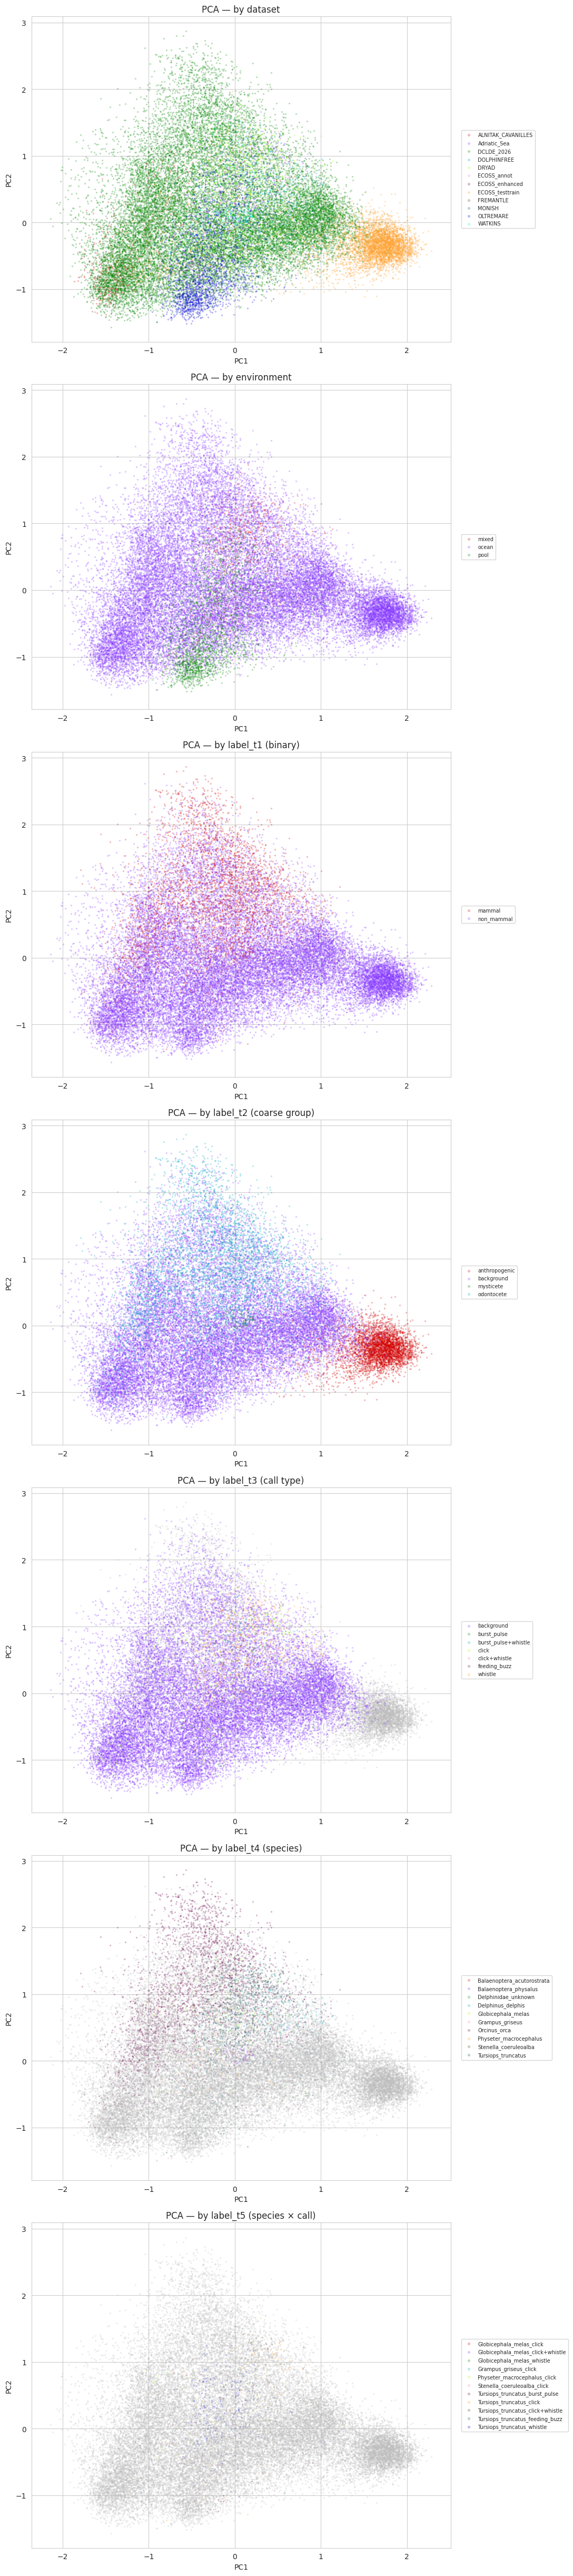

In [14]:
try:
    import colorcet as cc
    GLASBEY = [tuple(c) for c in cc.glasbey_bw_minc_20]
    def _palette(n): return GLASBEY[:n]
except ImportError:
    BASE = (sns.color_palette('tab20') + sns.color_palette('tab20b') + sns.color_palette('tab20c'))
    def _palette(n): return BASE[:n]

def scatter_by(plot_meta, X2, color_col, title, ax, max_classes=20, s=2, alpha=0.2):
    cats = plot_meta[color_col].fillna('__nan__').astype(str)
    top  = cats.value_counts().head(max_classes).index
    cats = cats.where(cats.isin(top), other='_other')
    uniq = sorted(cats.unique())
    palette = _palette(len(uniq))
    for c, color in zip(uniq, palette):
        if c in ('__nan__', '_other'):
            color = (0.75, 0.75, 0.75)
        m = (cats == c).values
        ax.scatter(X2[m,0], X2[m,1], s=s, alpha=alpha, color=color, label=c)
    ax.set_title(title); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=7, markerscale=2)

panels = [
    ('dataset',     'PCA — by dataset'),
    ('environment', 'PCA — by environment'),
    ('label_t1',    'PCA — by label_t1 (binary)'),
    ('label_t2',    'PCA — by label_t2 (coarse group)'),
    ('label_t3',    'PCA — by label_t3 (call type)'),
    ('label_t4',    'PCA — by label_t4 (species)'),
    ('label_t5',    'PCA — by label_t5 (species × call)'),
]

fig, axes = plt.subplots(len(panels), 1, figsize=(11, 7 * len(panels)))
for ax, (col, title) in zip(axes, panels):
    scatter_by(plot_meta, X2, col, title, ax)
plt.tight_layout(); plt.show()


2026-05-12 15:13:46.298973: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-12 15:13:46.346744: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-12 15:13:47.763169: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


fitting UMAP...


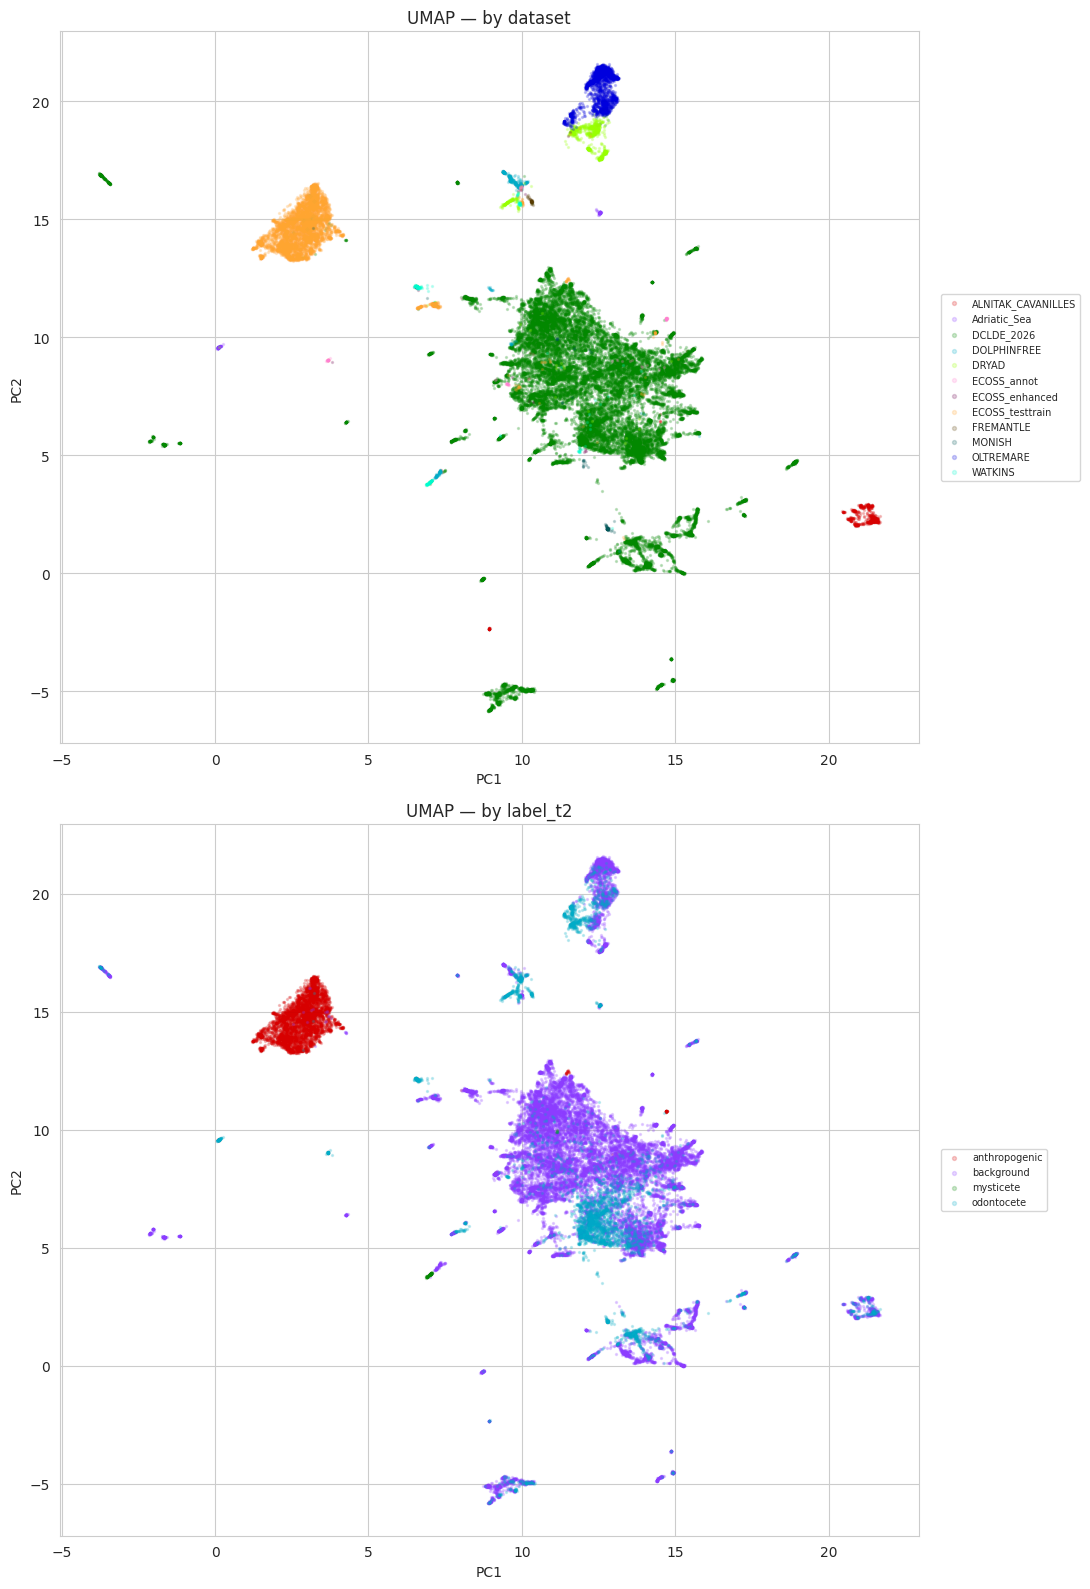

In [15]:
# Optional: UMAP for nonlinear structure. Skipped by default (slow on 30k).
RUN_UMAP = True
if RUN_UMAP:
    try:
        import umap
        print("fitting UMAP...")
        reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=0, n_jobs=-1)
        X2u = reducer.fit_transform(X_all[plot_idx])
        fig, axes = plt.subplots(2, 1, figsize=(11, 16))
        scatter_by(plot_meta, X2u, 'dataset',  'UMAP — by dataset',  axes[0])
        scatter_by(plot_meta, X2u, 'label_t2', 'UMAP — by label_t2', axes[1])
        plt.tight_layout(); plt.show()
    except ImportError:
        print("`pip install umap-learn` to enable UMAP")


## 4. Group-aware train/val/test split

Random shuffling of windows leaks temporal autocorrelation (adjacent 5-s windows from the same WAV are nearly identical). We split by **recording session / source file** so that all windows from one recording stay together.

Group key resolution per dataset:
- `wav_path` for most (Adriatic, DOLPHINFREE, DRYAD, OLTREMARE, FREMANTLE, ECOSS_testtrain, DCLDE)
- `wav_name` or `deployment_id` for ALNITAK
- `source_file` for MONISH / WATKINS
- `source` (FLAC) for ECOSS_annot / ECOSS_enhanced


In [16]:
def group_key(row):
    ds = row['dataset']
    if ds in ('MONISH', 'WATKINS'):
        return f"{ds}::{row.get('source_file')}"
    if ds in ('ECOSS_annot', 'ECOSS_enhanced'):
        return f"{ds}::{row.get('source')}"
    if ds == 'ALNITAK_CAVANILLES':
        # deployment is the cleanest grouping unit
        return f"{ds}::{row.get('deployment_id', row.get('wav_name'))}"
    # default: per-WAV
    return f"{ds}::{row.get('wav_path')}"

meta_all['group_key'] = meta_all.apply(group_key, axis=1)
print(f"groups: {meta_all['group_key'].nunique():,}")
print("\n  groups per dataset:")
print(meta_all.groupby('dataset')['group_key'].nunique().to_string())


groups: 4,234

  groups per dataset:
dataset
ALNITAK_CAVANILLES      49
Adriatic_Sea             1
DCLDE_2026            1952
DOLPHINFREE            275
DRYAD                   58
ECOSS_annot             94
ECOSS_enhanced         149
ECOSS_testtrain        738
FREMANTLE                1
MONISH                 185
OLTREMARE              281
WATKINS                451


In [17]:
def split_by_group(meta_subset, test_size=0.2, val_size=0.1, random_state=42):
    '''Returns (train_idx, val_idx, test_idx) into meta_subset's positional index.'''
    groups = meta_subset['group_key'].values
    # First split off the test set
    gss1 = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    trval_pos, test_pos = next(gss1.split(np.zeros(len(meta_subset)), groups=groups))
    # Then carve val from train
    val_frac = val_size / (1 - test_size)
    gss2 = GroupShuffleSplit(n_splits=1, test_size=val_frac, random_state=random_state)
    sub_groups = groups[trval_pos]
    tr_rel, va_rel = next(gss2.split(np.zeros(len(trval_pos)), groups=sub_groups))
    train_pos = trval_pos[tr_rel]
    val_pos   = trval_pos[va_rel]
    return train_pos, val_pos, test_pos


## 5. The probing pipeline

Two probes, identical interface:
- **Linear probe** — sklearn LogisticRegression on standardized X
- **MLP probe** — 2-layer MLP (1536 → 512 → 256 → n_classes), Adam, dropout, early stopping

Both wrapped in `run_probe(tier, model_kind, ...)` so the same call works for every tier.


In [18]:
class MLP(nn.Module):
    def __init__(self, in_dim, n_classes, hidden=(512, 256), dropout=0.3):
        super().__init__()
        layers, prev = [], in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)


def _train_mlp(Xtr, ytr, Xva, yva, n_classes, hidden=(512,256), dropout=0.3,
               lr=1e-3, weight_decay=1e-4, batch_size=512, epochs=60, patience=8,
               class_weight=True, verbose=False):
    model = MLP(Xtr.shape[1], n_classes, hidden=hidden, dropout=dropout).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    if class_weight:
        counts = np.bincount(ytr, minlength=n_classes).astype(np.float32)
        w = (counts.sum() / (n_classes * np.clip(counts, 1, None)))
        w = torch.tensor(w, dtype=torch.float32, device=DEVICE)
        crit = nn.CrossEntropyLoss(weight=w)
    else:
        crit = nn.CrossEntropyLoss()
    tr_ds = TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(ytr))
    va_ds = TensorDataset(torch.from_numpy(Xva), torch.from_numpy(yva))
    tr_dl = DataLoader(tr_ds, batch_size=batch_size, shuffle=True,  num_workers=0, pin_memory=False)
    va_dl = DataLoader(va_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)
    best_f1, best_state, bad = -1, None, 0
    history = []
    for ep in range(1, epochs+1):
        model.train(); tr_loss = 0.0; n = 0
        for xb, yb in tr_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward(); opt.step()
            tr_loss += loss.item() * xb.size(0); n += xb.size(0)
        model.eval(); preds, trues = [], []
        with torch.no_grad():
            for xb, yb in va_dl:
                p = model(xb.to(DEVICE)).argmax(1).cpu().numpy()
                preds.append(p); trues.append(yb.numpy())
        preds = np.concatenate(preds); trues = np.concatenate(trues)
        va_f1 = f1_score(trues, preds, average='macro', zero_division=0)
        history.append({'epoch': ep, 'train_loss': tr_loss/n, 'val_macro_f1': va_f1})
        if verbose:
            print(f"  ep{ep:02d}  loss={tr_loss/n:.4f}  val_f1={va_f1:.4f}")
        if va_f1 > best_f1 + 1e-4:
            best_f1, best_state, bad = va_f1, {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= patience: break
    if best_state is not None: model.load_state_dict(best_state)
    return model, history, best_f1


def _predict_mlp(model, X, batch_size=2048):
    model.eval(); out_logits = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.from_numpy(X[i:i+batch_size]).to(DEVICE)
            out_logits.append(model(xb).cpu().numpy())
    return np.concatenate(out_logits, axis=0)


In [19]:
def run_probe(tier, model_kind='mlp', min_class_count=10, verbose=False, **kwargs):
    '''Run one probe end-to-end and return a results dict.

    tier:        one of 'label_t1' ... 'label_t5'
    model_kind:  'linear' | 'mlp'
    min_class_count: drop classes with fewer than this many samples in train
    '''
    print(f"\n=== {tier} | {model_kind} ===")
    sub = meta_all.dropna(subset=[tier]).copy()
    print(f"  rows: {len(sub):,}")

    # Encode labels
    le = LabelEncoder()
    sub['y'] = le.fit_transform(sub[tier].astype(str))
    n_classes_raw = len(le.classes_)
    print(f"  classes (raw): {n_classes_raw}")

    # Split BEFORE filtering rare classes (filter using train counts)
    tr_pos, va_pos, te_pos = split_by_group(sub)
    print(f"  split: train={len(tr_pos)}  val={len(va_pos)}  test={len(te_pos)}")

    # Drop classes that are too rare in train
    tr_y = sub.iloc[tr_pos]['y'].values
    counts = pd.Series(tr_y).value_counts()
    keep = counts[counts >= min_class_count].index.tolist()
    if len(keep) < n_classes_raw:
        dropped = [le.classes_[i] for i in range(n_classes_raw) if i not in keep]
        print(f"  dropping {len(dropped)} rare classes (<{min_class_count} in train): {dropped}")
    mask = sub['y'].isin(keep)
    sub = sub[mask].reset_index(drop=True)
    # re-encode contiguous after dropping
    le2 = LabelEncoder().fit(sub[tier].astype(str))
    sub['y'] = le2.transform(sub[tier].astype(str))
    classes = list(le2.classes_)
    n_classes = len(classes)

    # Re-do the split on the filtered frame (groups unchanged)
    tr_pos, va_pos, te_pos = split_by_group(sub)
    rows_tr = sub.iloc[tr_pos]['row'].values
    rows_va = sub.iloc[va_pos]['row'].values
    rows_te = sub.iloc[te_pos]['row'].values
    Xtr, Xva, Xte = X_all[rows_tr], X_all[rows_va], X_all[rows_te]
    ytr = sub.iloc[tr_pos]['y'].values.astype(np.int64)
    yva = sub.iloc[va_pos]['y'].values.astype(np.int64)
    yte = sub.iloc[te_pos]['y'].values.astype(np.int64)

    # Standardize on train
    sc = StandardScaler().fit(Xtr)
    Xtr_s, Xva_s, Xte_s = sc.transform(Xtr), sc.transform(Xva), sc.transform(Xte)

    t0 = time.time()
    if model_kind == 'linear':
        clf = LogisticRegression(max_iter=2000, class_weight='balanced', n_jobs=-1,
                                 multi_class='auto', solver='lbfgs')
        clf.fit(Xtr_s.astype(np.float32), ytr)
        ypr = clf.predict(Xte_s.astype(np.float32))
        ypr_va = clf.predict(Xva_s.astype(np.float32))
        proba_te = clf.predict_proba(Xte_s.astype(np.float32)) if n_classes <= 50 else None
        history = None
    elif model_kind == 'mlp':
        model, history, best_va = _train_mlp(
            Xtr_s.astype(np.float32), ytr,
            Xva_s.astype(np.float32), yva,
            n_classes=n_classes, verbose=verbose, **kwargs)
        logits_te = _predict_mlp(model, Xte_s.astype(np.float32))
        logits_va = _predict_mlp(model, Xva_s.astype(np.float32))
        ypr    = logits_te.argmax(1)
        ypr_va = logits_va.argmax(1)
        proba_te = torch.softmax(torch.from_numpy(logits_te), dim=1).numpy()
    else:
        raise ValueError(model_kind)
    elapsed = time.time() - t0

    # ---- Metrics ----
    macro_f1   = f1_score(yte, ypr, average='macro',    zero_division=0)
    weight_f1  = f1_score(yte, ypr, average='weighted', zero_division=0)
    val_macro  = f1_score(yva, ypr_va, average='macro', zero_division=0)
    print(f"  trained in {elapsed:.1f}s | val_macro_f1={val_macro:.3f}  test_macro_f1={macro_f1:.3f}  test_weighted_f1={weight_f1:.3f}")

    return {
        'tier': tier, 'model_kind': model_kind,
        'classes': classes, 'n_classes': n_classes,
        'val_macro_f1': float(val_macro),
        'test_macro_f1': float(macro_f1),
        'test_weighted_f1': float(weight_f1),
        'history': history,
        'yte': yte, 'ypr': ypr, 'proba_te': proba_te,
        'rows_te': rows_te,
        'elapsed_s': elapsed,
    }


## 6. Train every tier × every model

This trains 8 models (4 tiers × 2 model kinds). On GPU each MLP takes 1–3 min on the full data; logistic is similar.


In [20]:
TIERS  = ['label_t1', 'label_t2', 'label_t3', 'label_t4', 'label_t5']
MODELS = ['linear', 'mlp']

results = {}
for tier in TIERS:
    for mk in MODELS:
        key = f"{tier}__{mk}"
        results[key] = run_probe(tier, model_kind=mk, verbose=False)

# Summary table
summary = pd.DataFrame([
    {'tier': r['tier'], 'model': r['model_kind'], 'n_classes': r['n_classes'],
     'val_macro_f1': r['val_macro_f1'],
     'test_macro_f1': r['test_macro_f1'],
     'test_weighted_f1': r['test_weighted_f1']}
    for r in results.values()
])
print("\n" + "="*70)
print(summary.to_string(index=False))
summary.to_csv(OUT_DIR / 'summary.csv', index=False)



=== label_t1 | linear ===
  rows: 247,630
  classes (raw): 2
  split: train=173316  val=23930  test=50384
  trained in 86.7s | val_macro_f1=0.816  test_macro_f1=0.802  test_weighted_f1=0.878

=== label_t1 | mlp ===
  rows: 247,630
  classes (raw): 2
  split: train=173316  val=23930  test=50384
  trained in 61.8s | val_macro_f1=0.853  test_macro_f1=0.849  test_weighted_f1=0.913

=== label_t2 | linear ===
  rows: 247,630
  classes (raw): 4
  split: train=173316  val=23930  test=50384
  trained in 309.7s | val_macro_f1=0.909  test_macro_f1=0.902  test_weighted_f1=0.884

=== label_t2 | mlp ===
  rows: 247,630
  classes (raw): 4
  split: train=173316  val=23930  test=50384
  trained in 52.3s | val_macro_f1=0.912  test_macro_f1=0.900  test_weighted_f1=0.898

=== label_t3 | linear ===
  rows: 188,808
  classes (raw): 7
  split: train=135394  val=19527  test=33887
  trained in 314.4s | val_macro_f1=0.329  test_macro_f1=0.386  test_weighted_f1=0.967

=== label_t3 | mlp ===
  rows: 188,808
  cl

## 7. Evaluation — per-class metrics, confusion matrices, dataset-stratified F1

For each trained model we report:
- per-class precision / recall / F1
- confusion matrix (heatmap)
- macro F1 broken down by `dataset` (this is the most important diagnostic — it tells you where the model generalizes vs overfits)



  label_t1 | linear
              precision    recall  f1-score   support

      mammal      0.559     0.901     0.690      8266
  non_mammal      0.978     0.860     0.915     42118

    accuracy                          0.867     50384
   macro avg      0.768     0.881     0.802     50384
weighted avg      0.909     0.867     0.878     50384



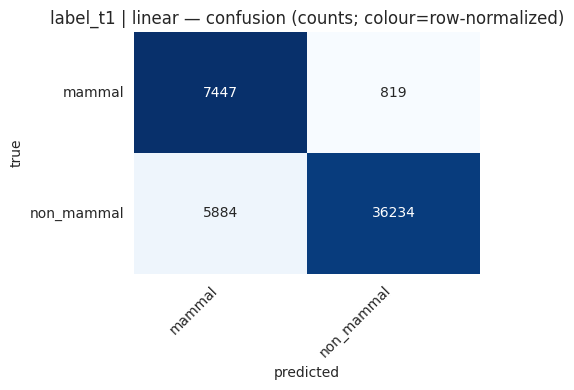


  macro-F1 by dataset (test set):
    ALNITAK_CAVANILLES      n=   496  macro_f1=0.353
    DCLDE_2026              n= 37305  macro_f1=0.806
    DOLPHINFREE             n=   619  macro_f1=0.804
    DRYAD                   n=  2829  macro_f1=0.687
    ECOSS_annot             n=    71  macro_f1=0.704
    ECOSS_enhanced          n=    35  macro_f1=1.000
    ECOSS_testtrain         n=  5181  macro_f1=0.846
    MONISH                  n=   153  macro_f1=0.480
    OLTREMARE               n=  3480  macro_f1=0.779
    WATKINS                 n=   215  macro_f1=0.499

  macro-F1 by region:
    cantabric     n=   619  macro_f1=0.804
    med           n=  3976  macro_f1=0.712
    mixed         n=  8484  macro_f1=0.827
    ne_pacific    n= 37305  macro_f1=0.806

  label_t1 | mlp
              precision    recall  f1-score   support

      mammal      0.677     0.850     0.754      8266
  non_mammal      0.969     0.920     0.944     42118

    accuracy                          0.909     50384
   m

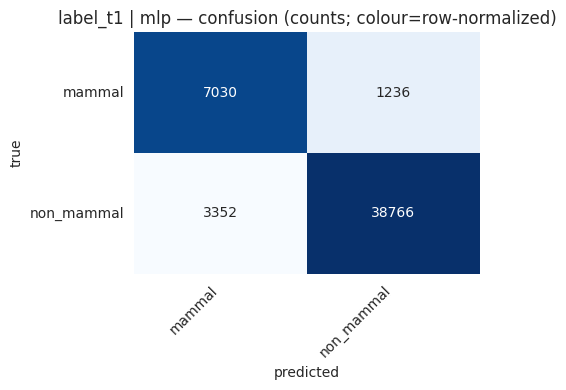


  macro-F1 by dataset (test set):
    ALNITAK_CAVANILLES      n=   496  macro_f1=0.383
    DCLDE_2026              n= 37305  macro_f1=0.839
    DOLPHINFREE             n=   619  macro_f1=0.866
    DRYAD                   n=  2829  macro_f1=0.878
    ECOSS_annot             n=    71  macro_f1=0.938
    ECOSS_enhanced          n=    35  macro_f1=0.892
    ECOSS_testtrain         n=  5181  macro_f1=0.976
    MONISH                  n=   153  macro_f1=1.000
    OLTREMARE               n=  3480  macro_f1=0.857
    WATKINS                 n=   215  macro_f1=0.498

  macro-F1 by region:
    cantabric     n=   619  macro_f1=0.866
    med           n=  3976  macro_f1=0.773
    mixed         n=  8484  macro_f1=0.934
    ne_pacific    n= 37305  macro_f1=0.839

  label_t2 | linear
               precision    recall  f1-score   support

anthropogenic      0.999     0.998     0.998      4880
   background      0.972     0.854     0.910     37238
    mysticete      1.000     1.000     1.000        6

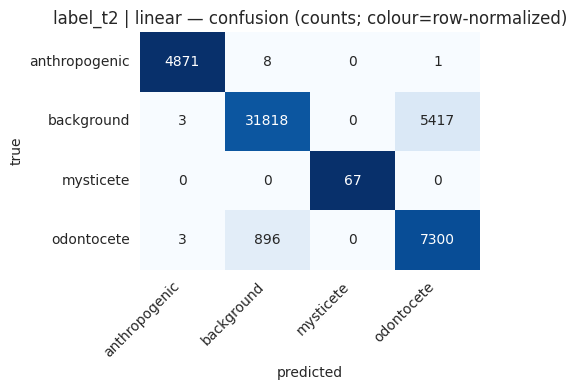


  macro-F1 by dataset (test set):
    ALNITAK_CAVANILLES      n=   496  macro_f1=0.395
    DCLDE_2026              n= 37305  macro_f1=0.542
    DOLPHINFREE             n=   619  macro_f1=0.816
    DRYAD                   n=  2829  macro_f1=0.706
    ECOSS_annot             n=    71  macro_f1=0.488
    ECOSS_enhanced          n=    35  macro_f1=0.656
    ECOSS_testtrain         n=  5181  macro_f1=0.910
    MONISH                  n=   153  macro_f1=0.485
    OLTREMARE               n=  3480  macro_f1=0.795
    WATKINS                 n=   215  macro_f1=0.666

  macro-F1 by region:
    cantabric     n=   619  macro_f1=0.816
    med           n=  3976  macro_f1=0.730
    mixed         n=  8484  macro_f1=0.878
    ne_pacific    n= 37305  macro_f1=0.542

  label_t2 | mlp
               precision    recall  f1-score   support

anthropogenic      0.999     0.998     0.999      4880
   background      0.975     0.874     0.922     37238
    mysticete      0.917     0.985     0.950        67
 

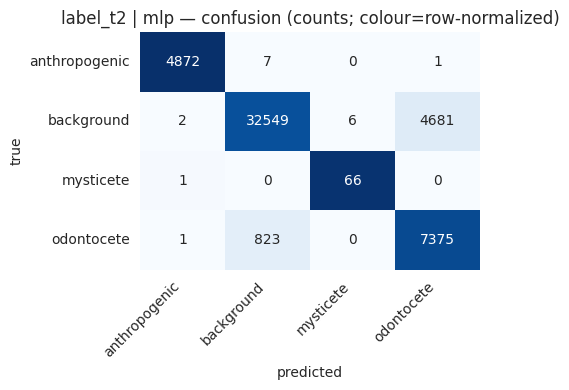


  macro-F1 by dataset (test set):
    ALNITAK_CAVANILLES      n=   496  macro_f1=0.385
    DCLDE_2026              n= 37305  macro_f1=0.415
    DOLPHINFREE             n=   619  macro_f1=0.570
    DRYAD                   n=  2829  macro_f1=0.761
    ECOSS_annot             n=    71  macro_f1=0.537
    ECOSS_enhanced          n=    35  macro_f1=0.662
    ECOSS_testtrain         n=  5181  macro_f1=0.972
    MONISH                  n=   153  macro_f1=0.657
    OLTREMARE               n=  3480  macro_f1=0.826
    WATKINS                 n=   215  macro_f1=0.664

  macro-F1 by region:
    cantabric     n=   619  macro_f1=0.570
    med           n=  3976  macro_f1=0.756
    mixed         n=  8484  macro_f1=0.904
    ne_pacific    n= 37305  macro_f1=0.415

  label_t3 | linear
                     precision    recall  f1-score   support

         background      0.995     0.971     0.983     32698
        burst_pulse      0.113     0.243     0.155       136
burst_pulse+whistle      0.478     

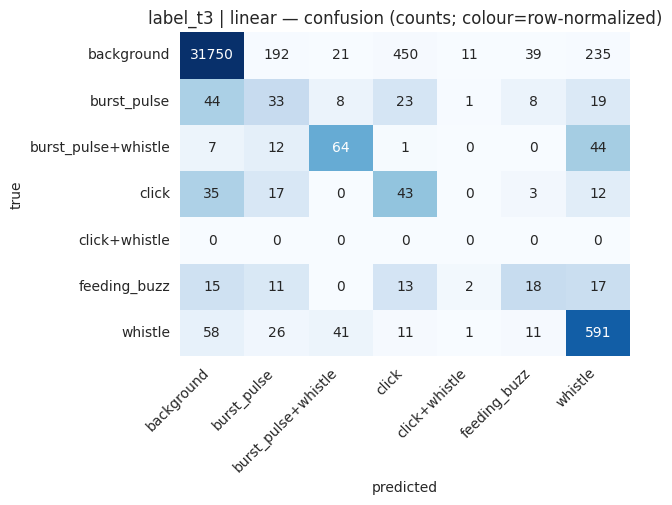


  macro-F1 by dataset (test set):
    ALNITAK_CAVANILLES      n=   275  macro_f1=0.053
    DCLDE_2026              n= 28712  macro_f1=0.143
    DOLPHINFREE             n=   631  macro_f1=0.341
    DRYAD                   n=   531  macro_f1=0.315
    ECOSS_testtrain         n=   558  macro_f1=0.197
    OLTREMARE               n=  3180  macro_f1=0.314

  macro-F1 by region:
    cantabric     n=   631  macro_f1=0.341
    med           n=  3455  macro_f1=0.295
    mixed         n=  1089  macro_f1=0.336
    ne_pacific    n= 28712  macro_f1=0.143

  label_t3 | mlp
                     precision    recall  f1-score   support

         background      1.000     0.948     0.973     32698
        burst_pulse      0.085     0.566     0.147       136
burst_pulse+whistle      0.584     0.703     0.638       128
              click      0.093     0.427     0.152       110
      click+whistle      0.000     0.000     0.000         0
       feeding_buzz      0.212     0.618     0.315        76
      

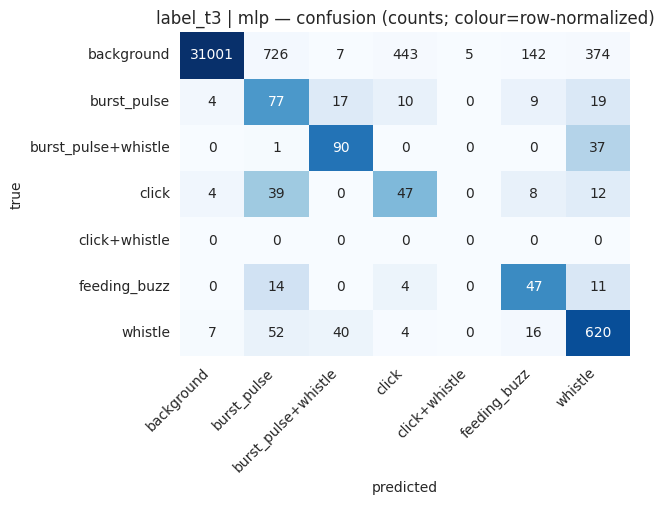


  macro-F1 by dataset (test set):
    ALNITAK_CAVANILLES      n=   275  macro_f1=0.001
    DCLDE_2026              n= 28712  macro_f1=0.250
    DOLPHINFREE             n=   631  macro_f1=0.550
    DRYAD                   n=   531  macro_f1=0.355
    ECOSS_testtrain         n=   558  macro_f1=0.246
    OLTREMARE               n=  3180  macro_f1=0.350

  macro-F1 by region:
    cantabric     n=   631  macro_f1=0.550
    med           n=  3455  macro_f1=0.274
    mixed         n=  1089  macro_f1=0.403
    ne_pacific    n= 28712  macro_f1=0.250

  label_t4 | linear
                            precision    recall  f1-score   support

Balaenoptera_acutorostrata      1.000     1.000     1.000         4
     Balaenoptera_physalus      1.000     1.000     1.000        84
       Delphinidae_unknown      0.676     0.893     0.769        28
         Delphinus_delphis      0.934     0.957     0.945       280
        Globicephala_melas      0.817     0.940     0.874       100
           Grampus_gri

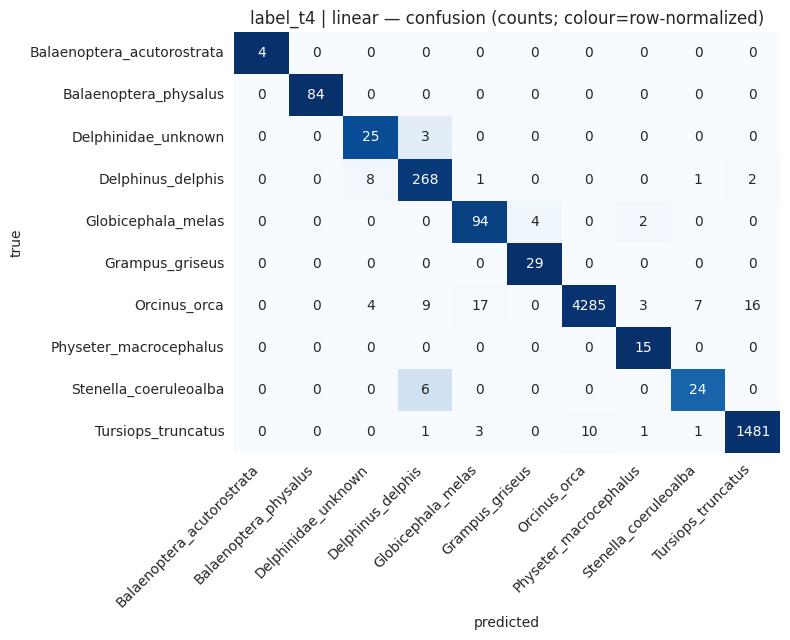


  macro-F1 by dataset (test set):
    DCLDE_2026              n=  4316  macro_f1=0.142
    DOLPHINFREE             n=   239  macro_f1=0.499
    DRYAD                   n=   820  macro_f1=0.165
    ECOSS_annot             n=    23  macro_f1=1.000
    ECOSS_enhanced          n=    27  macro_f1=0.705
    ECOSS_testtrain         n=    26  macro_f1=0.733
    MONISH                  n=    99  macro_f1=0.905
    OLTREMARE               n=   657  macro_f1=0.500
    WATKINS                 n=   201  macro_f1=0.876

  macro-F1 by region:
    cantabric     n=   239  macro_f1=0.499
    med           n=   657  macro_f1=0.500
    mixed         n=  1196  macro_f1=0.883
    ne_pacific    n=  4316  macro_f1=0.142

  label_t4 | mlp
                            precision    recall  f1-score   support

Balaenoptera_acutorostrata      1.000     1.000     1.000         4
     Balaenoptera_physalus      1.000     1.000     1.000        84
       Delphinidae_unknown      0.737     1.000     0.848        28
  

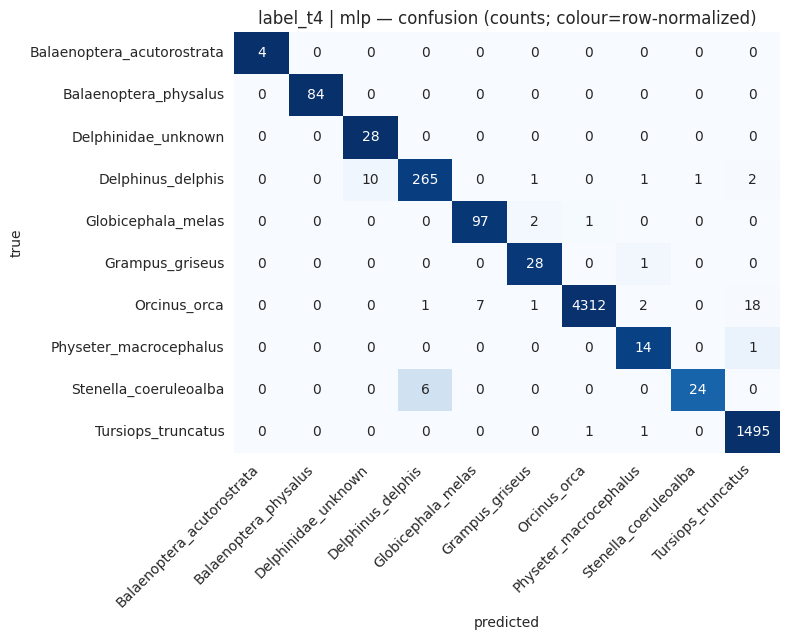


  macro-F1 by dataset (test set):
    DCLDE_2026              n=  4316  macro_f1=0.166
    DOLPHINFREE             n=   239  macro_f1=1.000
    DRYAD                   n=   820  macro_f1=0.333
    ECOSS_annot             n=    23  macro_f1=1.000
    ECOSS_enhanced          n=    27  macro_f1=1.000
    ECOSS_testtrain         n=    26  macro_f1=0.589
    MONISH                  n=    99  macro_f1=0.944
    OLTREMARE               n=   657  macro_f1=1.000
    WATKINS                 n=   201  macro_f1=0.875

  macro-F1 by region:
    cantabric     n=   239  macro_f1=1.000
    med           n=   657  macro_f1=1.000
    mixed         n=  1196  macro_f1=0.899
    ne_pacific    n=  4316  macro_f1=0.166

  label_t5 | linear
                                 precision    recall  f1-score   support

       Globicephala_melas_click      0.794     0.614     0.692        44
     Globicephala_melas_whistle      0.440     0.524     0.478        21
          Grampus_griseus_click      1.000     0.318

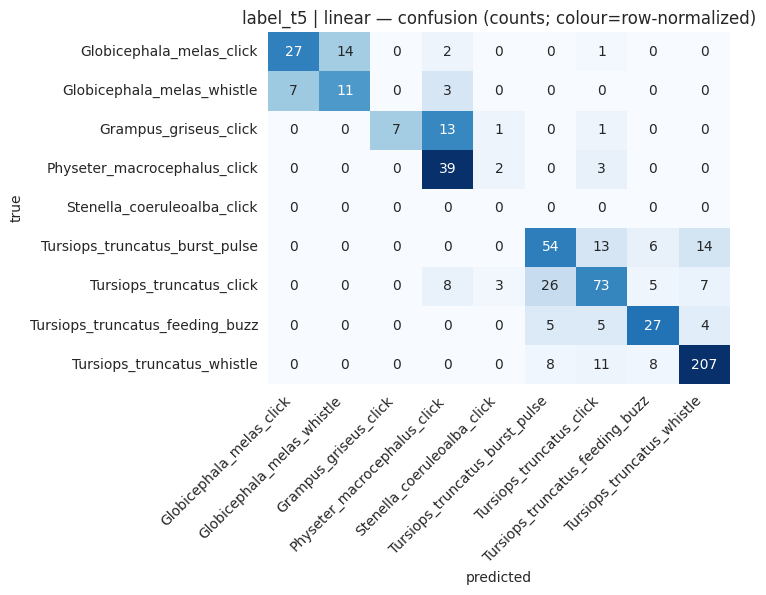


  macro-F1 by dataset (test set):
    ALNITAK_CAVANILLES      n=   143  macro_f1=0.413
    OLTREMARE               n=   472  macro_f1=0.698

  macro-F1 by region:
    med           n=   615  macro_f1=0.568

  label_t5 | mlp
                                 precision    recall  f1-score   support

       Globicephala_melas_click      0.738     0.705     0.721        44
     Globicephala_melas_whistle      0.368     0.333     0.350        21
          Grampus_griseus_click      0.800     0.364     0.500        22
   Physeter_macrocephalus_click      0.655     0.864     0.745        44
    Stenella_coeruleoalba_click      0.000     0.000     0.000         0
 Tursiops_truncatus_burst_pulse      0.663     0.632     0.647        87
       Tursiops_truncatus_click      0.776     0.738     0.756       122
Tursiops_truncatus_feeding_buzz      0.557     0.829     0.667        41
     Tursiops_truncatus_whistle      0.922     0.855     0.887       234

                       accuracy            

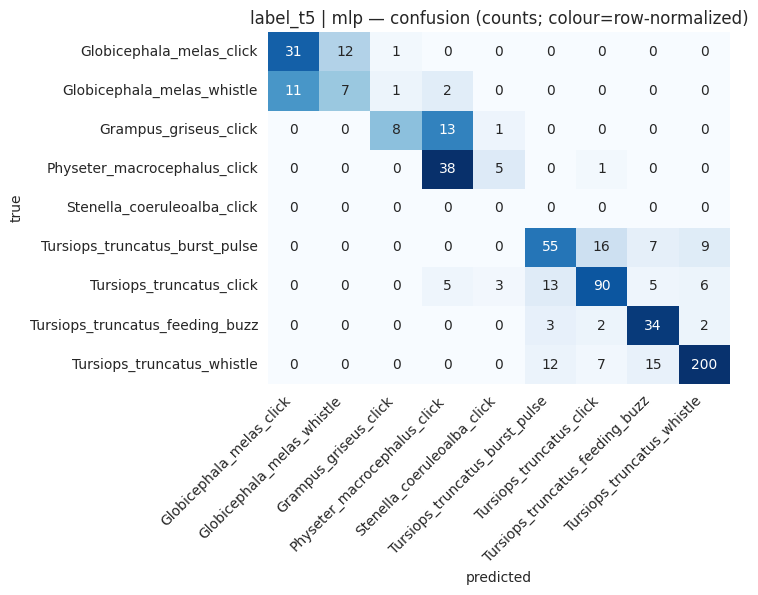


  macro-F1 by dataset (test set):
    ALNITAK_CAVANILLES      n=   143  macro_f1=0.464
    OLTREMARE               n=   472  macro_f1=0.745

  macro-F1 by region:
    med           n=   615  macro_f1=0.586


In [21]:
def report_one(result):
    tier  = result['tier']
    mk    = result['model_kind']
    yte   = result['yte']; ypr = result['ypr']
    classes = result['classes']
    rows_te = result['rows_te']

    print(f"\n{'='*70}\n  {tier} | {mk}\n{'='*70}")
    print(classification_report(yte, ypr, target_names=classes, digits=3, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(yte, ypr, labels=list(range(len(classes))))
    cm_norm = cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None)
    fig, ax = plt.subplots(figsize=(max(5, 0.5*len(classes)+3), max(4, 0.45*len(classes)+2)))
    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=ax, cbar=False)
    ax.set_xlabel('predicted'); ax.set_ylabel('true')
    ax.set_title(f'{tier} | {mk} — confusion (counts; colour=row-normalized)')
    plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
    plt.tight_layout(); plt.show()

    # Dataset-stratified macro F1
    test_meta = meta_all.iloc[rows_te].copy()
    test_meta['y']    = yte
    test_meta['ypr']  = ypr
    print("\n  macro-F1 by dataset (test set):")
    for ds, g in test_meta.groupby('dataset'):
        if len(g) < 20: continue
        f = f1_score(g['y'].values, g['ypr'].values, average='macro', zero_division=0)
        print(f"    {ds:22s}  n={len(g):>6d}  macro_f1={f:.3f}")
    # Region-stratified
    print("\n  macro-F1 by region:")
    for rg, g in test_meta.groupby('region'):
        if len(g) < 50: continue
        f = f1_score(g['y'].values, g['ypr'].values, average='macro', zero_division=0)
        print(f"    {rg:12s}  n={len(g):>6d}  macro_f1={f:.3f}")


for key in [f"{t}__{m}" for t in TIERS for m in MODELS]:
    report_one(results[key])


## 8. Binary tier — ROC AUC

For `label_t1` (mammal vs non_mammal) we also report ROC-AUC, which doesn't depend on threshold choice.


In [22]:
for mk in ['linear', 'mlp']:
    r = results[f'label_t1__{mk}']
    classes = r['classes']
    if r.get('proba_te') is None or len(classes) != 2: continue
    pos_idx = classes.index('mammal') if 'mammal' in classes else 1
    y_true_bin = (r['yte'] == pos_idx).astype(int)
    y_score    = r['proba_te'][:, pos_idx]
    auc = roc_auc_score(y_true_bin, y_score)
    print(f"  label_t1 | {mk}: ROC-AUC = {auc:.4f}")


  label_t1 | linear: ROC-AUC = 0.9464
  label_t1 | mlp: ROC-AUC = 0.9538


## 9. Persist artifacts

Saves:
- per-tier `predictions_<tier>_<model>.parquet` (true label, predicted label, row id, dataset, group_key) — for downstream error analysis
- `meta_all_with_taxonomy.parquet` — the master frame with the four tier columns added
- `summary.csv` — bottom-line F1s

Model weights are *not* saved automatically — uncomment the torch.save lines below if you want them.


In [23]:
# ---------------------------------------------------------------------
# Persist the unified 5-tier taxonomy so downstream notebooks can load
# the same labels without re-running assign_labels().
# ---------------------------------------------------------------------
TAX_COLS = ['label_t1', 'label_t2', 'label_t3', 'label_t4', 'label_t5']

# 1) Full metadata + taxonomy (parquet)
meta_all.to_parquet(OUT_DIR / 'meta_all_with_taxonomy.parquet', index=False)
print(f"saved {OUT_DIR/'meta_all_with_taxonomy.parquet'}  ({len(meta_all):,} rows)")

# 2) Skinny taxonomy lookup (CSV).
id_cols = [c for c in ['dataset', 'group_key', 'row', 'global_idx',
                       'wav_path', 'wav_name', 'source_file', 'label']
           if c in meta_all.columns]
tax_only = meta_all[id_cols + TAX_COLS].copy()
tax_only.to_csv(OUT_DIR / 'unified_taxonomy.csv', index=False)
print(f"saved {OUT_DIR/'unified_taxonomy.csv'}")

# 3) Class vocabulary per tier + the lookup tables (JSON, source-of-truth)
import json as _json
vocab = {t: sorted(meta_all[t].dropna().astype(str).unique().tolist()) for t in TAX_COLS}
with open(OUT_DIR / 'taxonomy_vocabulary.json', 'w') as _f:
    _json.dump({
        'tiers': TAX_COLS,
        'tier_semantics': {
            'label_t1': 'binary mammal vs non_mammal',
            'label_t2': 'coarse group: odontocete/mysticete/pinniped/anthropogenic/background',
            'label_t3': 'call type: click/whistle/burst_pulse/feeding_buzz/pulsed_call/song/background',
            'label_t4': 'species (binomial); NaN for non-mammal rows',
            'label_t5': 'joint species_call (e.g. Tursiops_truncatus_whistle); restricted to T5_ELIGIBLE_DATASETS',
        },
        'classes_per_tier': vocab,
        't5_eligible_datasets': sorted(T5_ELIGIBLE_DATASETS),
        'dataset_species_table': DATASET_SPECIES,
        'species_taxonomy': SPECIES_TAXONOMY,
    }, _f, indent=2)
print(f"saved {OUT_DIR/'taxonomy_vocabulary.json'}")

# 4) Per-tier prediction parquets (keyed to new tier list)
for key, r in results.items():
    classes = r['classes']
    rows_te = r['rows_te']
    df = meta_all.iloc[rows_te][['dataset','region','environment','group_key'] + TAX_COLS].copy()
    df['y_true_idx'] = r['yte']
    df['y_pred_idx'] = r['ypr']
    df['y_true']     = [classes[i] for i in r['yte']]
    df['y_pred']     = [classes[i] for i in r['ypr']]
    fp = OUT_DIR / f"predictions_{key}.parquet"
    df.to_parquet(fp, index=False)
print(f"saved {len(results)} prediction files to {OUT_DIR.resolve()}")


saved mlp_runs/meta_all_with_taxonomy.parquet  (247,630 rows)
saved mlp_runs/unified_taxonomy.csv
saved mlp_runs/taxonomy_vocabulary.json
saved 10 prediction files to /data2/mromaniuc/cet-det/alltogether/preliminary/mlp_runs
